# ME 3300 Lab 03 — FirstName LastName

**Multichannel Measurement and Normal Acceleration**

Rename to `FirstName_LastName_Lab03.ipynb`, save in `ME3300/Lab_03/Code/`.
Fill in the `TODO`s following the manual. New syntax is in the Prelab 03
walkthrough.

> Close WaveForms before running dwfpy cells. Restart Kernel and Run All
> before submitting (acquisition cells keep their saved outputs).

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 10

## Part 3 — dwfpy connection test 
### Connection Test (7.1)

In [54]:
import dwfpy as dwf
with dwf.Device() as device:
 print("Connected to:", device.name)

DeviceNotFound: Device not found

### Single Channel Read (7.2)

In [56]:
fs = 1000 # sample rate (Hz)
duration = 2.0 # seconds
n = int(fs * duration) # number of samples

with dwf.Device() as device:
 scope = device.analog_input # the Scope/Logger instrument

 scope['ch1'].setup(range=5.0) # enable Ch. 1, +/-5 V input range

 # Acquire one buffer: set the rate and size, configure, start, and wait
 scope.single(sample_rate=fs, buffer_size=n, configure=True, start=True)

 volts = scope['ch1'].get_data() # the samples, as a NumPy array
 print(f"mean = {volts.mean():.4f} V, std = {volts.std(ddof=1):.4f} V")


DeviceNotFound: Device not found

## Part 4 - Automated accelerometer calibration
### Aquire Four Calibration Points

Prompt through the four orientations of manual Fig. 4, record 10 s at 20 Hz
each, store the mean voltages.

In [ ]:
positions = ['right', 'up', 'left', 'down']
known_accel = [0.0, 9.81, 0.0, -9.81] # m/s^2
mean_voltages = []

fs, duration = 20, 10.0
n = int(fs * duration)

with dwf.Device() as device:
 scope = device.analog_input
 scope['ch1'].setup(range=5.0) 
# TODO: open the device with a 'with' block, then set up the accelerometer
# channel: scope = device.analog_input
# scope['ch2'].setup(range=5.0)
# TODO: loop with zip(positions, known_accel):
# - input() prompt to position the pendulum
# - scope.single(sample_rate=fs, buffer_size=n,
# configure=True, start=True)
# - append the mean of scope['ch2'].get_data() to mean_voltages
# TODO: convert mean_voltages to np.array
# TODO: save known_accel & mean_voltages with np.column_stack + np.savetxt

In [ ]:
from numpy.random import sample
positions = ['right', 'up', 'left', 'down']
known_accel = [0.0, 9.81, 0.0, -9.81] # m/s^2
mean_voltages = []

fs, duration = 20, 10.0
n = int(fs * duration)

with dwf.Device() as device:
 scope = device.analog_input
 scope['ch2'].setup(range=5.0) 

 for pos, accel in zip(positions, known_accel):
 input(f"Hold Pendulum '{pos}' ({accel:+.2f} m/s^2), then press Enter...")

 scope.single(sample_rate=fs, buffer_size=n, configure=True, start=True)

 volts = scope['ch2'].get_data()
 mean_voltages.append(volts.mean())
 print(f" {pos}: {mean_voltages[-1]:.4f} V")

mean_voltages = np.array(mean_voltages)

# Save the raw calibration table for your records
np.savetxt('../Data/accel_calibration_data_test.csv',
 np.column_stack([known_accel,mean_voltages]),
 header='accel_m_per_s2,voltage_V', delimiter=',')

 right: 1.6416 V
 up: 1.4469 V
 left: 1.6441 V
 down: 1.8586 V


### 8.2 Fit and Plot Calibration

In [ ]:
# --- Fit the calibration (manual Eq. 3; stats per Lab 02) ---
# TODO: polyfit voltage -> acceleration
# TODO: N, nu, residuals, norm_r, s_yx, t_val (careful: 0.975!), CI, S_a1
# TODO: print equation + stats with units; save coeffs with np.savetxt

In [57]:
# -- Load data
data = np.loadtxt("../Data/accel_calibration_data_test.csv",delimiter=',',skiprows=1)
known_accel = data[:,0]
mean_voltages = data[:,1]

# --- Fit: ay = a1*x+a0 ---
coeffs = np.polyfit(mean_voltages,known_accel,1)
accels_fit = np.polyval(coeffs,mean_voltages)

# save coeffs
np.savetxt('../Data/calibration_coeffs.csv', coeffs,
           header='a1 ((m/s^2)/V), a0 (m/s^2)', delimiter=',')

# --- Fit quality ---
N = len(accels_fit)
nu = N - 2
resid = known_accel - accels_fit
norm_r = np.sqrt(np.sum(resid**2))
s_yx = norm_r / np.sqrt(nu)
t_val = stats.t.ppf(0.975,df=nu)
CI = t_val*s_yx
S_a1 = s_yx / np.sqrt(np.sum((mean_voltages - np.mean(mean_voltages))**2))

print(f"Calibration: ay = {coeffs[0]:.2f} V + {coeffs[1]:.2f}")
print(f"CI = {CI:.2f} m/s^2")
print(f"norm = {norm_r:.2f} m/s^2")
print(f"s_yx = {s_yx:.2f} m/s^2")
print(f"S_a1 = {S_a1:.2f} m/s^2/V")


Calibration: ay = -47.60 V + 78.43
CI = 1.45 m/s^2
norm = 0.48 m/s^2
s_yx = 0.34 m/s^2
S_a1 = 1.16 m/s^2/V


In [ ]:
# --- Calibration plot ---
# TODO: build to match the manual example figure; save .pdf/.png at 600 DPI

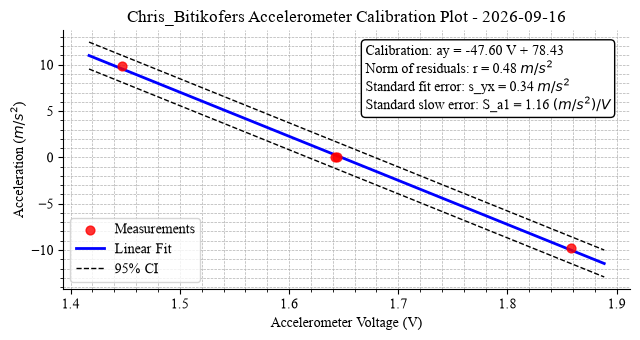

In [58]:
fig1, ax1 = plt.subplots(figsize=(6.5, 3.5))
fig1.patch.set_facecolor('white')

# markers data
ax1.scatter(mean_voltages,known_accel,
    color = 'red', s = 40, alpha = 0.8, zorder = 3,
    label = f'Measurements')

# fit line
v_rng = np.linspace(mean_voltages.min()-0.03, mean_voltages.max()+0.03,200) # sample points for a line
a_fit = np.polyval(coeffs,v_rng)
ax1.plot(v_rng,a_fit,'b-',linewidth = 2, label = 'Linear Fit')

# CI lines
ax1.plot(v_rng,a_fit+CI,'k--',linewidth = 1, label = '95% CI')
ax1.plot(v_rng,a_fit-CI,'k--',linewidth = 1)

# Labels, grid and formats
ax1.set_xlabel('Accelerometer Voltage (V)')
ax1.set_ylabel('Acceleration ($m/s^2$)')
ax1.set_title('Chris_Bitikofer''s Accelerometer Calibration Plot - 2026-09-16')

ax1.grid(True, which='both', linestyle='--',linewidth=0.5)

ax1.minorticks_on()

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

plt.tight_layout()

# Legend
ax1.legend(loc = 'lower left')

# Text Annotation
txt = (
    f'Calibration: ay = {coeffs[0]:.2f} V + {coeffs[1]:.2f}\n'
    f'Norm of residuals: r = {norm_r:.2f} $m/s^2$\n'
    f'Standard fit error: s_yx = {s_yx:.2f} $m/s^2$\n'
    f'Standard slow error: S_a1 = {S_a1:.2f} $(m/s^2)/V$'
    )
ax1.text(1.67,8.5,txt,
    fontsize=10,
    ha="left",
    va='center',
    bbox=dict(boxstyle='round',ec='k',fc='w')
    )

# save figure
fig1.savefig('../Figures/Chris_Bitikofer_Lab03_AccelCalibration.pdf',
            dpi=600, bbox_inches='tight')

fig1.savefig('../Figures/Chris_Bitikofer_Lab03_AccelCalibration.png',
            dpi=600, bbox_inches='tight')

plt.show()

## Part 5 — Swing capture (WaveForms Scope Record mode)

No code — follow the manual. Export as
`FirstName_LastName_Lab03_Swing.csv`, then open it and count the `#` header
lines for `skiprows` below.

## Part 6 — Post-processing

In [ ]:
# TODO: np.loadtxt both calibration coefficient files (comments='#')
# - pot calibration is in your Lab_02/Data folder!
# TODO: pd.read_csv the swing file (check skiprows), extract 3 columns
# TODO: apply both calibrations with np.polyval

In [59]:
pot_coeffs = np.loadtxt('../../../Lab_02/SolutionPackage_TA/Data/calibration_coeffs.csv',
                        delimiter=',',comments='#')
acc_coeffs = np.loadtxt('../Data/calibration_coeffs.csv',
                        delimiter=',',comments='#')

swing = pd.read_csv('../Data/Swing_Recording_CKB.csv',skiprows=9)
time = swing.iloc[:,0]
v_pot = swing.iloc[:,1]
v_acc = swing.iloc[:,2]

angle_deg = np.polyval(pot_coeffs,v_pot)
accel_ms2 = np.polyval(acc_coeffs,v_acc)

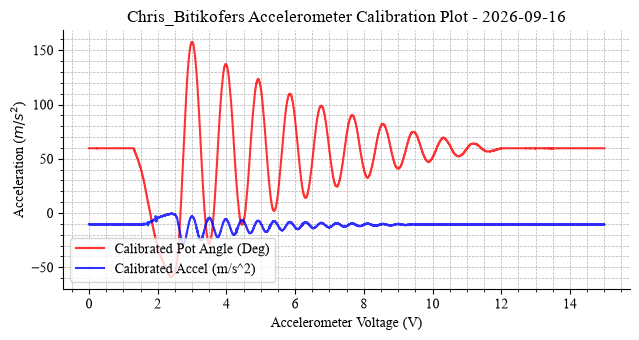

In [60]:
# plot it at this point to confirm calibration makes sense
fig , ax = plt.subplots(figsize=(6.5, 3.5))

# Pot angle data
ax.plot(time,angle_deg,
    color = 'red', alpha = 0.8,
    label = 'Calibrated Pot Angle (Deg)')

# Acc data
ax.plot(time,accel_ms2,
    color = 'b',alpha=0.8,
    label = 'Calibrated Accel (m/s^2)')

# Labels, grid and formats
ax.set_xlabel('Accelerometer Voltage (V)')
ax.set_ylabel('Acceleration ($m/s^2$)')
ax.set_title('Chris_Bitikofer''s Accelerometer Calibration Plot - 2026-09-16')

ax.grid(True, which='both', linestyle='--',linewidth=0.5)

ax.minorticks_on()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Legend
ax.legend(loc = 'lower left')

plt.show()

In [62]:
import plotly.graph_objects as go

# plot it at this point to confirm calibration makes sense
fig = go.Figure()

# Pot angle data
fig.add_trace(go.Scatter(
    x=time, y=angle_deg,
    mode='lines',
    name='Calibrated Pot Angle (Deg)',
    line=dict(color='red'),
    opacity=0.8,
    customdata=list(range(len(time))),
    hovertemplate='idx=%{customdata}<br>t=%{x:.4f}<br>angle=%{y:.3f} deg<extra></extra>'
))

# Accel data
fig.add_trace(go.Scatter(
    x=time, y=accel_ms2,
    mode='lines',
    name='Calibrated Accel (m/s^2)',
    line=dict(color='blue'),
    opacity=0.8,
    customdata=list(range(len(time))),
    hovertemplate='idx=%{customdata}<br>t=%{x:.4f}<br>accel=%{y:.3f} m/s^2<extra></extra>'
))

# Labels, title, legend, rangeslider for interactive trim inspection
fig.update_layout(
    title="Interactive Accelerometer Trim Plot",
    xaxis_title='Accelerometer Voltage (V)',
    yaxis_title='Acceleration (m/s^2)',
    legend=dict(x=0.01, y=0.01, xanchor='left', yanchor='bottom'),
    width=800, height=450,
    template='plotly_white',
    hovermode='x unified',
    xaxis=dict(rangeslider=dict(visible=True), showgrid=True, gridwidth=0.5, griddash='dash'),
    yaxis=dict(showgrid=True, gridwidth=0.5, griddash='dash')
)

fig.show()

In [ ]:
# --- Trim to release: deviation-from-hold detector ---
# (Lab 02's diff-threshold FAILS at 1 kHz -- see manual for why)
# TODO: hold_mean from the first ~500 samples of angle
# TODO: idx0 = np.argmax(np.abs(angle - hold_mean) > 2.0)
# TODO: slice t, theta (in RADIANS), a_meas from idx0; re-zero time

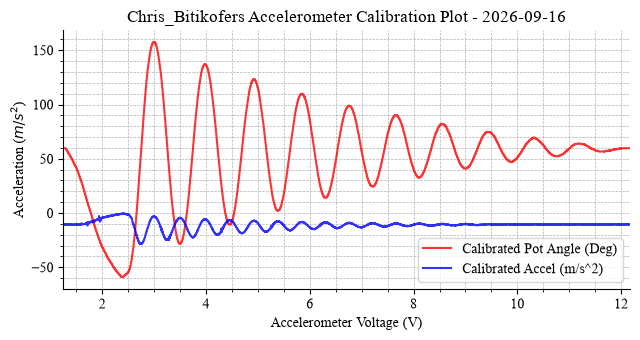

In [63]:
# from the plotly chart note the idx's to trim the recording down to the portion of data we are interested in
# then draw a new trimmed matplotlib chart

idx1 = 1250
idx2 = 12171
t = time[idx1:]-time[idx1] # shift time vector

# plot it at this point to confirm calibration makes sense
fig , ax = plt.subplots(figsize=(6.5, 3.5))

# Pot angle data
ax.plot(time[idx1:idx2],angle_deg[idx1:idx2],
    color = 'red', alpha = 0.8,
    label = 'Calibrated Pot Angle (Deg)')

# Acc data
ax.plot(time[idx1:idx2],accel_ms2[idx1:idx2],
    color = 'b',alpha=0.8,
    label = 'Calibrated Accel (m/s^2)')

# Labels, grid and formats
ax.set_xlabel('Accelerometer Voltage (V)')
ax.set_ylabel('Acceleration ($m/s^2$)')
ax.set_title('Chris_Bitikofer''s Accelerometer Calibration Plot - 2026-09-16')

ax.set_xlim((time[idx1],time[idx2]))

ax.grid(True, which='both', linestyle='--',linewidth=0.5)

ax.minorticks_on()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Legend
ax.legend(loc = 'lower right')

plt.show()


59.705410717050356
1319
[1.0069817  1.0069817  1.0069817  ... 1.04206769 1.04206769 1.04206769]
[-10.59652652 -10.77450768 -10.77450768 ... -10.59652652 -10.41854535
 -10.59652652]


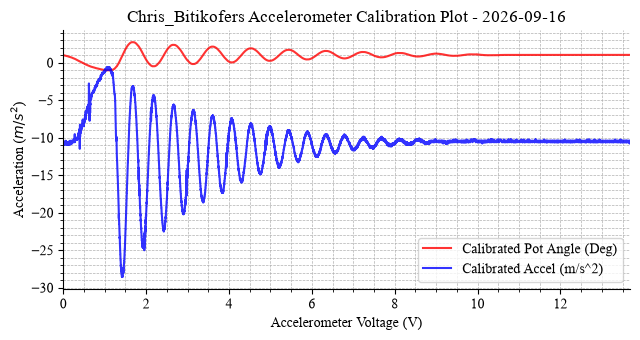

In [64]:
# 10.3 Detector Trim
hold_mean = angle_deg[:500].mean()
print(hold_mean)
moved = np.abs(angle_deg-hold_mean) > 2.0
idx0 = np.argmax(moved)
print(idx0)

t = time[idx0:] - time[idx0]
theta = np.radians(angle_deg[idx0:])
a_meas = accel_ms2[idx0:]

print(theta)
print(a_meas)

# plot it at this point to confirm calibration makes sense
fig , ax = plt.subplots(figsize=(6.5, 3.5))

# Pot angle data
ax.plot(t,theta,
    color = 'red', alpha = 0.8,
    label = 'Calibrated Pot Angle (Deg)')

# Acc data
ax.plot(t,a_meas,
    color = 'b',alpha=0.8,
    label = 'Calibrated Accel (m/s^2)')

# Labels, grid and formats
ax.set_xlabel('Accelerometer Voltage (V)')
ax.set_ylabel('Acceleration ($m/s^2$)')
ax.set_title('Chris_Bitikofer''s Accelerometer Calibration Plot - 2026-09-16')

ax.set_xlim((t.iloc[0],t.iloc[-1]))

ax.grid(True, which='both', linestyle='--',linewidth=0.5)

ax.minorticks_on()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Legend
ax.legend(loc = 'lower right')

plt.show()

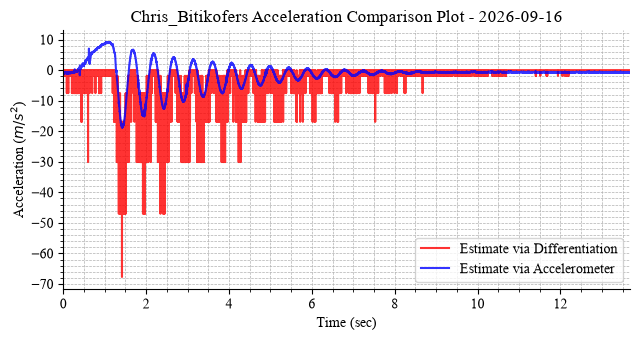

In [76]:
r = 220/1000 # TODO: YOUR measured pivot->accelerometer distance (m)
g = 9.81
dt = t.iloc[1] - t.iloc[0]


# TODO: theta_dot = np.gradient(theta, dt)
theta_dot = np.gradient(theta,dt)
# TODO: a_calc = -(theta_dot**2) * r (manual Eq. 1)
a_calc = -(theta_dot**2)*r
# TODO: a_meas_n = a_meas + g*np.cos(theta) (manual Eq. 2 rearranged)
a_meas_n = a_meas + g*np.cos(np.deg2rad(theta))
# --- Comparison plot ---
# TODO: plot a_calc FIRST (blue, 1 pt), then a_meas_n (red, 1.5 pt)
# TODO: format per Post-Lab requirements; save .pdf/.png at 600 DPI

# plot it at this point to confirm calibration makes sense
fig , ax = plt.subplots(figsize=(6.5, 3.5))

# Pot angle data
ax.plot(t,a_calc,
    color = 'red', alpha = 0.8,
    label = 'Estimate via Differentiation')

# Acc data
ax.plot(t,a_meas_n,
    color = 'b',alpha=0.8,
    label = 'Estimate via Accelerometer')

# Labels, grid and formats
ax.set_xlabel('Time (sec)')
ax.set_ylabel('Acceleration ($m/s^2$)')
ax.set_title('Chris_Bitikofer''s Acceleration Comparison Plot - 2026-09-16')

ax.set_xlim((t.iloc[0],t.iloc[-1]))

ax.grid(True, which='both', linestyle='--',linewidth=0.5)

ax.minorticks_on()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Legend
ax.legend(loc = 'lower right')

plt.show()